House Price Prediction using linear Regression Algorithm


Problem Statement

Predict house price based on:

Area
Bedrooms
Bathrooms
Age of house
Distance from city center

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

creating database

In [3]:
data = {
    "Area":[1000,1200,1500,1800,2000,2500,3000,3500,4000,4500],
    "Bedrooms":[2,2,3,3,4,4,5,5,6,6],
    "Bathrooms":[1,2,2,3,3,4,4,5,5,6],
    "Age":[20,18,15,12,10,8,6,5,4,2],
    "Distance":[15,14,12,10,8,7,5,4,3,2],
    "Price":[50,55,70,80,90,120,140,160,180,210]
}

df = pd.DataFrame(data)

print(df)

   Area  Bedrooms  Bathrooms  Age  Distance  Price
0  1000         2          1   20        15     50
1  1200         2          2   18        14     55
2  1500         3          2   15        12     70
3  1800         3          3   12        10     80
4  2000         4          3   10         8     90
5  2500         4          4    8         7    120
6  3000         5          4    6         5    140
7  3500         5          5    5         4    160
8  4000         6          5    4         3    180
9  4500         6          6    2         2    210


Step 3: Basic Data Inspection
shape

In [4]:
df.shape

(10, 6)

info

In [5]:
df.info


<bound method DataFrame.info of    Area  Bedrooms  Bathrooms  Age  Distance  Price
0  1000         2          1   20        15     50
1  1200         2          2   18        14     55
2  1500         3          2   15        12     70
3  1800         3          3   12        10     80
4  2000         4          3   10         8     90
5  2500         4          4    8         7    120
6  3000         5          4    6         5    140
7  3500         5          5    5         4    160
8  4000         6          5    4         3    180
9  4500         6          6    2         2    210>

statistics

In [6]:
df.describe()

,Area,Bedrooms,Bathrooms,Age,Distance,Price
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000
mean,2500.000000,4.000000,3.500000,10.000000,8.000000,115.50000
std,1210.142324,1.490712,1.581139,6.128259,4.618802,55.40006
min,1000.000000,2.000000,1.000000,2.000000,2.000000,50.00000
25%,1575.000000,3.000000,2.250000,5.250000,4.250000,72.50000
50%,2250.000000,4.000000,3.500000,9.000000,7.500000,105.00000
75%,3375.000000,5.000000,4.750000,14.250000,11.500000,155.00000
max,4500.000000,6.000000,6.000000,20.000000,15.000000,210.00000


Step 4: Check Missing Values

In [8]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Age          0
Distance     0
Price        0
dtype: int64

Step 5: Check Correlation

In [9]:
df.corr

<bound method DataFrame.corr of    Area  Bedrooms  Bathrooms  Age  Distance  Price
0  1000         2          1   20        15     50
1  1200         2          2   18        14     55
2  1500         3          2   15        12     70
3  1800         3          3   12        10     80
4  2000         4          3   10         8     90
5  2500         4          4    8         7    120
6  3000         5          4    6         5    140
7  3500         5          5    5         4    160
8  4000         6          5    4         3    180
9  4500         6          6    2         2    210>

heatmap

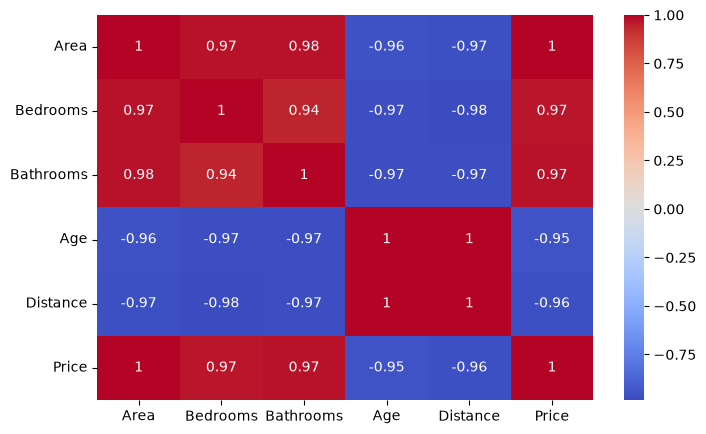

In [10]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

Step 6: Visualize Relationships
Area vs Price

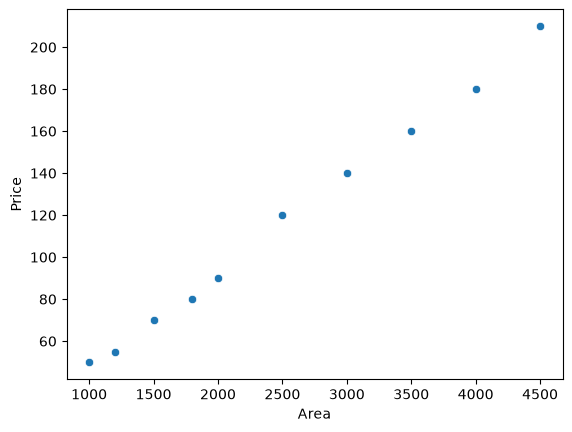

In [11]:
sns.scatterplot(
    data=df,
    x="Area",
    y="Price"
)

plt.show()

area vs price

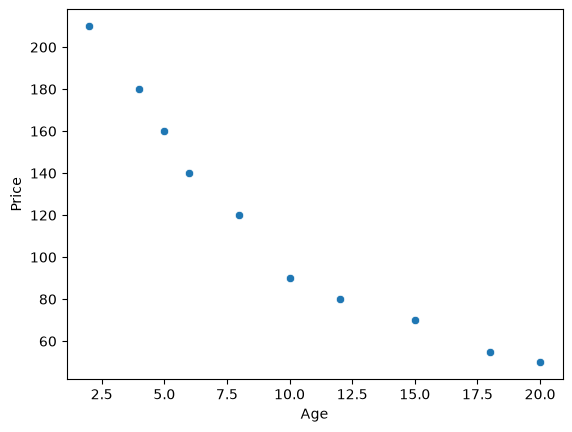

In [12]:
sns.scatterplot(
    data=df,
    x="Age",
    y="Price"
)

plt.show()

Step 7: Define X and y

In [13]:
X = df.drop("Price", axis=1)

In [15]:
print(X)

   Area  Bedrooms  Bathrooms  Age  Distance
0  1000         2          1   20        15
1  1200         2          2   18        14
2  1500         3          2   15        12
3  1800         3          3   12        10
4  2000         4          3   10         8
5  2500         4          4    8         7
6  3000         5          4    6         5
7  3500         5          5    5         4
8  4000         6          5    4         3
9  4500         6          6    2         2


In [16]:
y = df["Price"]

In [17]:
print(y)

0     50
1     55
2     70
3     80
4     90
5    120
6    140
7    160
8    180
9    210
Name: Price, dtype: int64


Step 8: Train Test Split

Interview Question:

Why split?

Answer: Evaluate model on unseen data.

In [18]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train)
print(X_test)
print(y_train)
print(y_test)

   Area  Bedrooms  Bathrooms  Age  Distance
5  2500         4          4    8         7
0  1000         2          1   20        15
7  3500         5          5    5         4
2  1500         3          2   15        12
9  4500         6          6    2         2
4  2000         4          3   10         8
3  1800         3          3   12        10
6  3000         5          4    6         5
   Area  Bedrooms  Bathrooms  Age  Distance
8  4000         6          5    4         3
1  1200         2          2   18        14
5    120
0     50
7    160
2     70
9    210
4     90
3     80
6    140
Name: Price, dtype: int64
8    180
1     55
Name: Price, dtype: int64


Step 9: Train Model

In [19]:
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.06,-1.55,-4.81,-2.12, 3. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Area','Bedrooms','Bathrooms','Age','Distance']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.438
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


Step 10: Understand Learned Equation

In [20]:
pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

,Feature,Coefficient
0,Area,0.055150
1,Bedrooms,-1.545064
2,Bathrooms,-4.806867
3,Age,-2.124464
4,Distance,3.004292


In [21]:
model.intercept_

np.float64(-1.4377682403427343)

Step 11: Make Predictions

In [22]:
y_pred = model.predict(X_test)

y_pred

array([186.37339056,  55.8583691 ])

Step 12: Compare Actual Vs Predicted

In [23]:
result = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

print(result)

   Actual   Predicted
8     180  186.373391
1      55   55.858369


Step 13: Evaluation Metrics

MAE

In [24]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print(mae)

3.615879828326147


MSE

In [25]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print(mse)

20.678452356830736


RMSE

In [26]:
rmse = np.sqrt(mse)

print(rmse)

4.54735663400516


R^2 Score


0 → Worst

1 → Perfect

In [27]:
r2 = r2_score(
    y_test,
    y_pred
)

print(r2)

0.9947063161966513


Step 14: Residual Analysis

Very Important

Residual: Ideal -Random scatter around zero.
Bad - curved pattern : Linear Regression unsuitable.


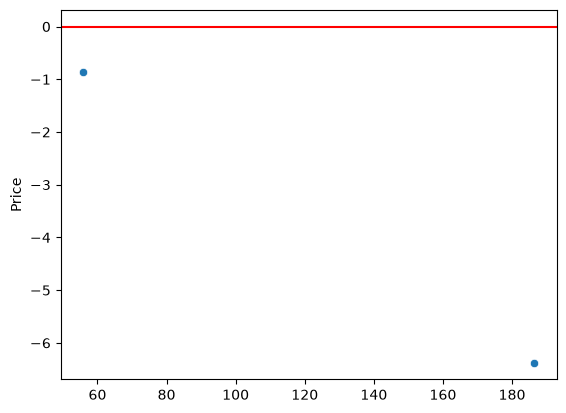

In [28]:
residuals = y_test - y_pred

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.show()

Step 15: Actual vs Predicted Plot

perfect model: Points lie on straight diagonal line

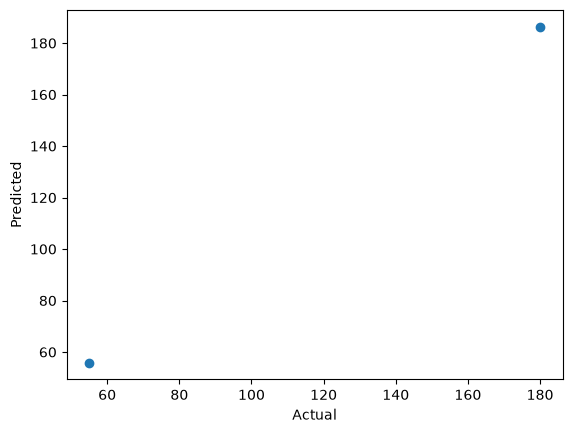

In [29]:
plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

Step 16: Predict New House

In [30]:
new_house = pd.DataFrame({
    "Area":[2200],
    "Bedrooms":[4],
    "Bathrooms":[3],
    "Age":[5],
    "Distance":[6]
})

prediction = model.predict(
    new_house
)

print(prediction)

[106.69527897]


Step 17: Save Model

In [ ]:
import joblib

joblib.dump(
    model,
    "house_price_model.pkl"
)

load and predict

In [ ]:
loaded_model = joblib.load(
    "house_price_model.pkl"
)

loaded_model.predict(
    new_house
)

Linear regression + regularization
Recommended Real-World Project
Employee Salary Prediction

Predict: Salary

using : Age
Experience
Education Years
Skill Score
Certification Count
Projects Completed
Performance Rating

Why this project?

✅ Business understandable

✅ Numerical target

✅ Multiple features

✅ Demonstrates all regression algorithms

✅ Feature selection possible

✅ Multicollinearity can be introduced

✅ Common interview problem


Phase 1: Generate Realistic Dataset

import libs and Create 1000 records.

In [36]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option("display.max_columns", None)

In [37]:
np.random.seed(42)

n = 1000

experience = np.random.randint(0, 20, n)

education_years = np.random.randint(12, 20, n)

skill_score = np.random.randint(50, 100, n)

certifications = np.random.randint(0, 10, n)

projects_completed = np.random.randint(1, 50, n)

performance_rating = np.random.randint(1, 6, n)

age = experience + np.random.randint(22, 30, n)

salary = (
    25000
    + experience * 5000
    + education_years * 1500
    + skill_score * 1200
    + certifications * 3000
    + projects_completed * 1000
    + performance_rating * 8000
    + np.random.normal(0, 15000, n)
)

df = pd.DataFrame({
    "Age": age,
    "Experience": experience,
    "EducationYears": education_years,
    "SkillScore": skill_score,
    "Certifications": certifications,
    "ProjectsCompleted": projects_completed,
    "PerformanceRating": performance_rating,
    "Salary": salary
})

df

,Age,Experience,EducationYears,SkillScore,Certifications,ProjectsCompleted,PerformanceRating,Salary
0,34,6,18,78,5,10,5,252040.043257
1,46,19,13,81,3,45,5,318478.155850
2,37,14,14,93,3,19,1,275418.521026
3,34,10,13,67,5,11,3,203522.552059
4,32,7,14,55,6,13,4,208594.799071
...,...,...,...,...,...,...,...,...
995,27,2,18,96,6,27,1,231403.764846
996,42,19,17,60,9,35,4,297572.859544
997,32,10,15,94,8,31,4,295463.477808
998,33,5,16,82,9,15,3,238862.070462


Cell 3: Basic Inspection

In [38]:
print(df.shape)

print("\n",df.info())

print("\n",df.describe())

(1000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Experience         1000 non-null   int64  
 2   EducationYears     1000 non-null   int64  
 3   SkillScore         1000 non-null   int64  
 4   Certifications     1000 non-null   int64  
 5   ProjectsCompleted  1000 non-null   int64  
 6   PerformanceRating  1000 non-null   int64  
 7   Salary             1000 non-null   float64
dtypes: float64(1), int64(7)
memory usage: 62.6 KB

 None

                Age   Experience  EducationYears   SkillScore  Certifications  \
count  1000.000000  1000.000000     1000.000000  1000.000000     1000.000000   
mean     34.642000     9.136000       15.433000    74.388000        4.459000   
std       6.310282     5.895953        2.304522    14.390224        2.834847   
min      22.000000     0.000000     

Cell 4: Missing Values

In [39]:
df.isnull().sum()

Age                  0
Experience           0
EducationYears       0
SkillScore           0
Certifications       0
ProjectsCompleted    0
PerformanceRating    0
Salary               0
dtype: int64

Cell 5: Correlation Analysis

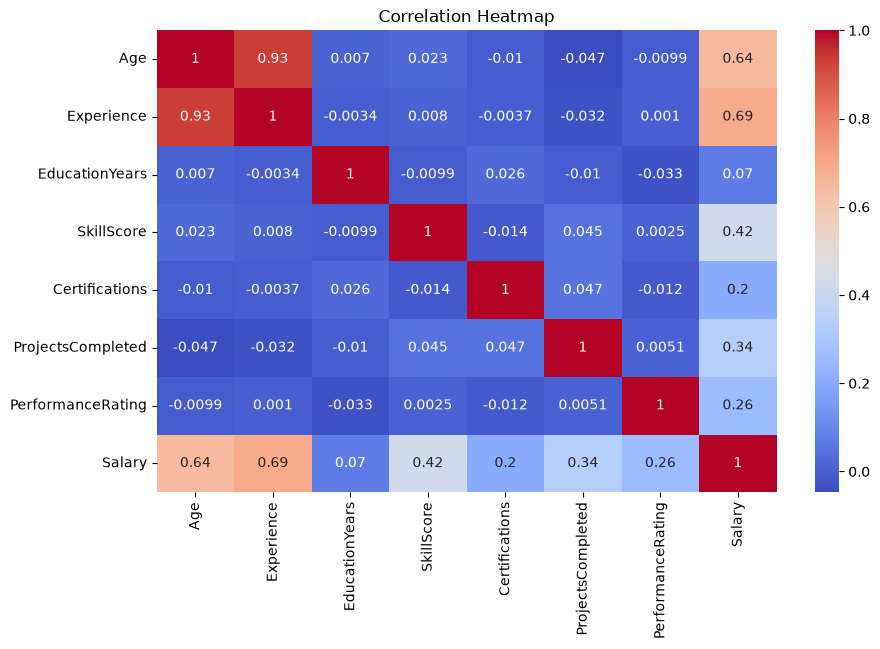

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


Cell 6: Simple Linear Regression

Using only Experience.

In [41]:
X_simple = df[["Experience"]]

y = df["Salary"]

simple_model = LinearRegression()

simple_model.fit(X_simple, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5056.92]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Cell 7: Visualize Simple Linear Regression

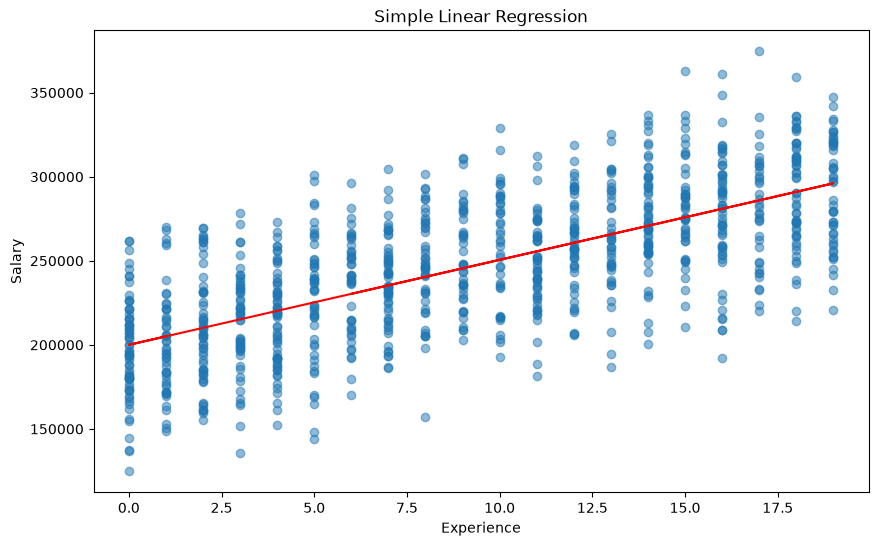

In [43]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_simple,
    y,
    alpha=0.5
)

plt.plot(
    X_simple,
    simple_model.predict(X_simple),
    color="red"
)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")

plt.show()


Cell 8: Simple LR Equation

In [44]:
print("Intercept:", simple_model.intercept_)

print("Coefficient:", simple_model.coef_[0])

Intercept: 200004.2836662694
Coefficient: 5056.924774507878


Cell 9: Multiple Linear Regression

All features.

In [45]:
X = df.drop("Salary", axis=1)

y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Cell 10: Train Multiple Linear Regression

In [46]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

Cell 11: Coefficient Interpretation

In [47]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coeff_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
6,PerformanceRating,7904.898214
1,Experience,5151.258580
4,Certifications,2841.952325
2,EducationYears,1475.699558
3,SkillScore,1224.222850
5,ProjectsCompleted,981.002013
0,Age,-31.579060


Cell 12: Ridge Regression

In [48]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

Cell 13: Lasso Regression

In [49]:
lasso_model = Lasso(alpha=100)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

Cell 14: Elastic Net

In [50]:
elastic_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

elastic_model.fit(X_train, y_train)

elastic_pred = elastic_model.predict(X_test)

Cell 15: Evaluation Function

In [51]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

Cell 16: Compare All Models

In [52]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Ridge",
        y_test,
        ridge_pred
    )
)

results.append(
    evaluate_model(
        "Lasso",
        y_test,
        lasso_pred
    )
)

results.append(
    evaluate_model(
        "Elastic Net",
        y_test,
        elastic_pred
    )
)

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,11109.714029,2.052025e+08,14324.891790,0.897673
1,Ridge,11109.649807,2.052211e+08,14325.540924,0.897663
2,Lasso,11109.793680,2.055989e+08,14338.720767,0.897475
3,Elastic Net,11107.365411,2.060348e+08,14353.911619,0.897257


Cell 17: Hyperparameter Tuning (Ridge)

In [53]:
params = {
    "alpha":[
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

grid = GridSearchCV(
    Ridge(),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Alpha: {'alpha': 1}
Best Score: 0.873093017974561


Cell 18: Residual Analysis

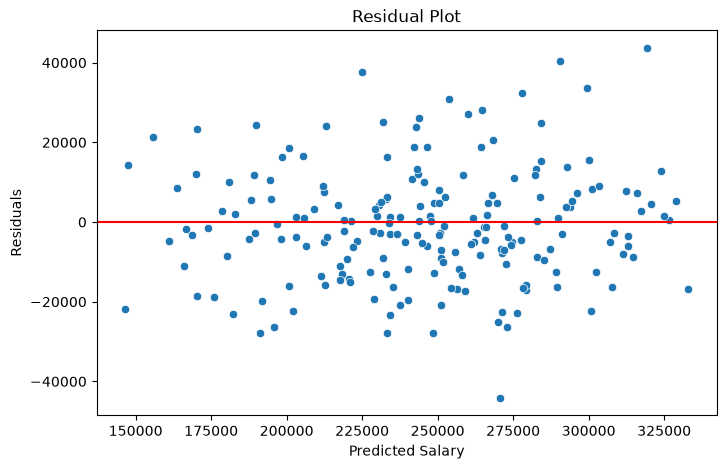

In [54]:
best_pred = linear_pred

residuals = y_test - best_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=best_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Cell 19: Actual vs Predicted

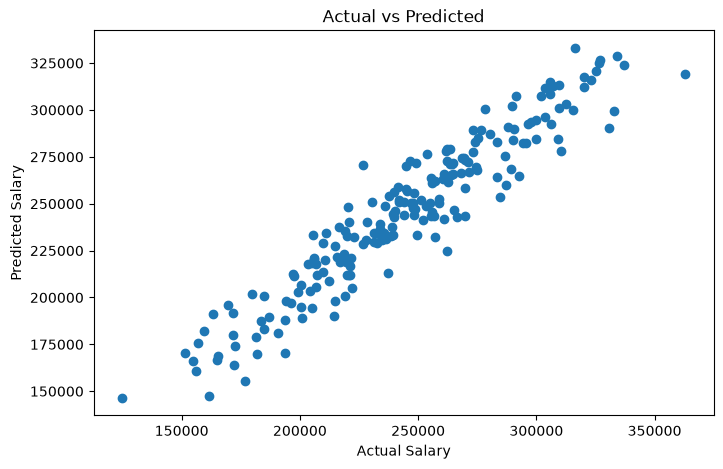

In [55]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    best_pred
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted")

plt.show()

Cell 20: Predict New Employee

In [ ]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Experience": [7],
    "EducationYears": [16],
    "SkillScore": [88],
    "Certifications": [4],
    "ProjectsCompleted": [18],
    "PerformanceRating": [4]
})

prediction = linear_model.predict(new_employee)

print(
    f"Predicted Salary: ₹{prediction,.0f}"
)

SyntaxError: invalid decimal literal (3753522648.py, line 16)